# 04 · Fine-tuning BioBERT for Medical NER

Fine-tunes `dmis-lab/biobert-base-cased-v1.1` for token classification on the MACCROBAT BIO data. Runs on the **Apple Silicon GPU (MPS)** when available, otherwise CUDA or CPU.

Sections: setup & data → model init → training loop → loss curve → test evaluation → save → inference demo.

## Setup and Data Loading

In [1]:
import json
import numpy as np
import torch
from torch.optim import AdamW
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoTokenizer, AutoModelForTokenClassification, get_scheduler
from sklearn.metrics import classification_report, accuracy_score
from tqdm.auto import tqdm

# --- Apple Silicon GPU (MPS) aware device selection ---
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
print("Using device:", device)

model_name = "dmis-lab/biobert-base-cased-v1.1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

with open("../data/label2id.json") as f:
    label2id = json.load(f)
with open("../data/id2label.json") as f:
    id2label = {int(k): v for k, v in json.load(f).items()}

def load_split(path):
    d = np.load(path)
    return TensorDataset(
        torch.tensor(d["input_ids"]),
        torch.tensor(d["attention_mask"]),
        torch.tensor(d["labels"]),
    )

batch_size = 8
train_loader = DataLoader(load_split("../data/train.npz"), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(load_split("../data/val.npz"),   batch_size=batch_size)
test_loader  = DataLoader(load_split("../data/test.npz"),  batch_size=batch_size)

/opt/homebrew/Caskroom/miniforge/base/envs/biobert-ner/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


## Model Initialisation and Configuration

In [2]:
model = AutoModelForTokenClassification.from_pretrained(
    model_name, num_labels=len(label2id), id2label=id2label, label2id=label2id
).to(device)

num_epochs = 5
optimizer = AdamW(model.parameters(), lr=5e-5)
num_training_steps = len(train_loader) * num_epochs
lr_scheduler = get_scheduler("linear", optimizer=optimizer,
                             num_warmup_steps=0, num_training_steps=num_training_steps)

Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training Loop

In [3]:
train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}\n" + "-"*30)
    model.train()
    total_train_loss = 0
    for batch in tqdm(train_loader, desc="Training", leave=False):
        input_ids, attention_mask, labels = [x.to(device) for x in batch]
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_train_loss += loss.item()
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss, val_preds, val_labels = 0, [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validating", leave=False):
            input_ids, attention_mask, labels = [x.to(device) for x in batch]
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_val_loss += outputs.loss.item()
            predictions = torch.argmax(outputs.logits, dim=-1)
            for i in range(labels.shape[0]):
                true = labels[i].cpu().numpy()
                pred = predictions[i].cpu().numpy()
                mask = true != -100
                val_preds.extend(pred[mask])
                val_labels.extend(true[mask])
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    acc = accuracy_score(val_labels, val_preds)
    val_accuracies.append(acc)
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {acc:.4f}")


Epoch 1/5
------------------------------


Train Loss: 1.1587 | Val Loss: 0.7860 | Val Acc: 0.7998

Epoch 2/5
------------------------------


Train Loss: 0.6253 | Val Loss: 0.6978 | Val Acc: 0.8145

Epoch 3/5
------------------------------


Train Loss: 0.4070 | Val Loss: 0.7172 | Val Acc: 0.8165

Epoch 4/5
------------------------------


Train Loss: 0.2705 | Val Loss: 0.7463 | Val Acc: 0.8138

Epoch 5/5
------------------------------


Train Loss: 0.1961 | Val Loss: 0.7802 | Val Acc: 0.8173


## Training / Validation Loss

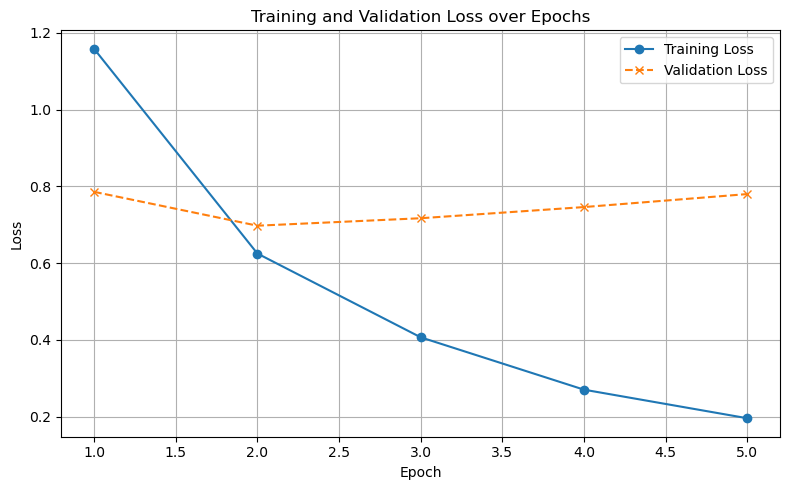

In [5]:
import os
from matplotlib import pyplot as plt
os.makedirs("../models", exist_ok=True)
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), train_losses, marker='o', linestyle='-', label='Training Loss')
plt.plot(range(1, num_epochs+1), val_losses, marker='x', linestyle='--', label='Validation Loss')
plt.title("Training and Validation Loss over Epochs")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("../models/training_loss_curve.png")
plt.show()

## Test-set Evaluation
Entity-level precision / recall / F1 (padding and `O` excluded).

In [6]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        predictions = torch.argmax(logits, dim=-1)
        for i in range(labels.shape[0]):
            true = labels[i].cpu().numpy()
            pred = predictions[i].cpu().numpy()
            mask = true != -100
            all_preds.extend(pred[mask])
            all_labels.extend(true[mask])

# Entity-level metrics (exclude padding and the "O" tag)
used = sorted(set(all_labels) | set(all_preds))
used = [i for i in used if i != -100 and i in id2label and id2label[i] != "O"]
report = classification_report(all_labels, all_preds, labels=used,
                               target_names=[id2label[i] for i in used],
                               output_dict=True, zero_division=0)
print("Model Evaluation Summary (entities only):")
print("-"*55)
print(f"{'Metric':<15}{'Precision':<12}{'Recall':<12}{'F1-Score':<12}")
print("-"*55)
for name in ("micro avg","macro avg","weighted avg"):
    r = report[name]
    print(f"{name:<15}{r['precision']:<12.4f}{r['recall']:<12.4f}{r['f1-score']:<12.4f}")
print("-"*55)
print(f"{'Token Acc':<15}{accuracy_score(all_labels, all_preds):<12.4f}")

Model Evaluation Summary (entities only):
-------------------------------------------------------
Metric         Precision   Recall      F1-Score    
-------------------------------------------------------
micro avg      0.6979      0.6992      0.6986      
macro avg      0.5322      0.4933      0.4905      
weighted avg   0.6893      0.6992      0.6894      
-------------------------------------------------------
Token Acc      0.8082      


## Save the Fine-tuned Model

In [7]:
output_dir = "../models/biobert_ner"
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)
with open(f"{output_dir}/label2id.json", "w") as f:
    json.dump(label2id, f, indent=2)
with open(f"{output_dir}/id2label.json", "w") as f:
    json.dump(id2label, f, indent=2)
print("Saved model to", output_dir)

Saved model to ../models/biobert_ner


## Inference Demo

In [8]:
def get_entities(words, tags):
    entities, entity, etype = [], [], None
    for word, tag in zip(words, tags):
        if tag.startswith("B-"):
            if entity: entities.append((" ".join(entity), etype))
            entity, etype = [word], tag[2:]
        elif tag.startswith("I-") and etype == tag[2:]:
            entity.append(word)
        else:
            if entity: entities.append((" ".join(entity), etype))
            entity, etype = [], None
    if entity: entities.append((" ".join(entity), etype))
    return entities

def predict_and_print(text):
    model.eval()
    words = text.split()
    enc = tokenizer(words, is_split_into_words=True, return_tensors="pt", truncation=True)
    word_ids = enc.word_ids()
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        preds = torch.argmax(model(**enc).logits, dim=-1)[0].tolist()
    tags, prev = [], None
    for idx, wid in enumerate(word_ids):
        if wid is None or wid == prev: continue
        tags.append(id2label.get(preds[idx], "O")); prev = wid
    print("Text:", text)
    for ent, etype in get_entities(words, tags):
        print(f"  - {ent!r:40} -> {etype}")
    print()

predict_and_print("The patient complained of fatigue and was admitted for observation.")
predict_and_print("The patient was extremely dehydrated due to immense summer heat.")

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Text: The patient complained of fatigue and was admitted for observation.
  - 'fatigue'                                -> SIG
  - 'admitted'                               -> CLE
  - 'observation.'                           -> CLE

Text: The patient was extremely dehydrated due to immense summer heat.
  - 'extremely'                              -> SEV
  - 'dehydrated'                             -> SIG
  - 'immense'                                -> SEV
  - 'summer'                                 -> FRE
  - 'heat.'                                  -> SIG

